In [70]:
import numpy as np
import pandas as pd
from scipy.stats import norm
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [71]:
df = pd.read_csv("/Users/genadit/Downloads/OptionChain.csv")


df.columns = df.columns.str.strip()

In [72]:
hdfc   = df[df['Stock'] == 'HDFCBANK'].reset_index(drop=True)
nestle = df[df['Stock'] == 'NESTLEIND'].reset_index(drop=True)
 
S_hdfc   = hdfc['Spot'].iloc[0]
S_nestle = nestle['Spot'].iloc[0]
r        = hdfc['RFR'].iloc[0]
 
# Expiry T values
T_hdfc_apr = hdfc[hdfc['Expiry'].str.contains('Apr')]['T (Years)'].iloc[0]
T_hdfc_may = hdfc[hdfc['Expiry'].str.contains('May')]['T (Years)'].iloc[0]
T_ne_apr   = nestle[nestle['Expiry'].str.contains('Apr')]['T (Years)'].iloc[0]
 
# Volatilities (Historical)
vol_hdfc   = hdfc['Vol (Hist)'].iloc[0]
vol_nestle = nestle['Vol (Hist)'].iloc[0]
 
print(f"HDFCBANK  : Spot={S_hdfc}, r={r:.6f}, T_apr={T_hdfc_apr}, vol={vol_hdfc}")
print(f"NESTLEIND : Spot={S_nestle}, r={r:.6f}, T_apr={T_ne_apr}, vol={vol_nestle}")


HDFCBANK  : Spot=810.0, r=0.067833, T_apr=0.035616, vol=0.173032
NESTLEIND : Spot=1256.9, r=0.067833, T_apr=0.035616, vol=0.160031


In [45]:
def bsm(S, K, r, sigma, T, opt_type):
    if T <= 0 or sigma <= 0:
        price = max(S-K, 0) if opt_type == 'Call' else max(K-S, 0)
        delta = 1.0 if opt_type == 'Call' else -1.0
        return price, delta, 0.0, 0.0
    d1    = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2    = d1 - sigma*np.sqrt(T)
    nd1   = norm.pdf(d1)
    gamma = nd1 / (S * sigma * np.sqrt(T))
    vega  = S * nd1 * np.sqrt(T) / 100
    if opt_type == 'Call':
        price = S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
        delta = norm.cdf(d1)
    else:
        price = K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)
        delta = norm.cdf(d1) - 1
    return price, delta, gamma, vega

In [73]:
HDFC_PORT = [
    (-1, 'Short', 'Call', 810, T_hdfc_apr, vol_hdfc, 'Short 1x Apr Call @810 (ATM)'),
    (+1, 'Long',  'Call', 875, T_hdfc_apr, vol_hdfc, 'Long  1x Apr Call @875 (OTM)'),
    (-1, 'Short', 'Put',  810, T_hdfc_apr, vol_hdfc, 'Short 1x Apr Put  @810 (ATM)'),
    (+1, 'Long',  'Put',  750, T_hdfc_apr, vol_hdfc, 'Long  1x Apr Put  @750 (OTM)'),
]
 

In [74]:

NESTLE_PORT = [
    (-1, 'Short', 'Call', 1170, T_ne_apr, vol_nestle, 'Short 1x Apr Call @1170 (lower wing)'),
    (+2, 'Long',  'Call', 1260, T_ne_apr, vol_nestle, 'Long  2x Apr Call @1260 (body)'),
    (-1, 'Short', 'Call', 1350, T_ne_apr, vol_nestle, 'Short 1x Apr Call @1350 (upper wing)'),
]

In [75]:
hdfc_shares   = -hdfc_delta
nestle_shares = -nestle_delta
 
print("\n" + "="*70)
print("DELTA HEDGE")
print("="*70)
print(f"  HDFCBANK")
print(f"    Pre-hedge delta  : {hdfc_delta:+.6f}")
print(f"    Action           : {'BUY' if hdfc_shares > 0 else 'SELL'} {abs(hdfc_shares):.4f} shares @ Rs.{S_hdfc:.2f}")
print(f"    Hedge cost       : Rs.{hdfc_shares * S_hdfc:+,.2f}")
print(f"    Post-hedge delta : {hdfc_delta + hdfc_shares:+.6f}  (target: 0)")
 
print(f"\n  NESTLEIND")
print(f"    Pre-hedge delta  : {nestle_delta:+.6f}")
print(f"    Action           : {'BUY' if nestle_shares > 0 else 'SELL'} {abs(nestle_shares):.4f} shares @ Rs.{S_nestle:.2f}")
print(f"    Hedge cost       : Rs.{nestle_shares * S_nestle:+,.2f}")
print(f"    Post-hedge delta : {nestle_delta + nestle_shares:+.6f}  (target: 0)")


DELTA HEDGE
  HDFCBANK
    Pre-hedge delta  : -0.067662
    Action           : BUY 0.0677 shares @ Rs.810.00
    Hedge cost       : Rs.+54.81
    Post-hedge delta : +0.000000  (target: 0)

  NESTLEIND
    Pre-hedge delta  : +0.006026
    Action           : SELL 0.0060 shares @ Rs.1256.90
    Hedge cost       : Rs.-7.57
    Post-hedge delta : +0.000000  (target: 0)


 def price_portfolio(legs, S, r):
    rows = []
    net_val = net_delta = net_gamma = net_vega = 0
    for qty, direction, otype, K, T, vol, label in legs:
        p, d, g, v = bsm(S, K, r, vol, T, otype)
        rows.append({
            'Leg'      : label,
            'Qty'      : qty,
            'BSM Price': round(p, 4),
            'Delta'    : round(d, 6),
            'Gamma'    : round(g, 6),$
            'Vega'     : round(v, 6),
            'Net Value': round(qty*p, 4),
            'Net Delta': round(qty*d, 6),
            'Net Gamma': round(qty*g, 6),
            'Net Vega' : round(qty*v, 6),
        })
        net_val   += qty * p
        net_delta += qty * d
        net_gamma += qty * g
        net_vega  += qty * v
 
    result_df = pd.DataFrame(rows)
    totals = pd.DataFrame([{
        'Leg': '── PORTFOLIO TOTAL ──', 'Qty': '',
        'BSM Price': '', 'Delta': '', 'Gamma': '', 'Vega': '',
        'Net Value': round(net_val, 4),
        'Net Delta': round(net_delta, 6),
        'Net Gamma': round(net_gamma, 6),
        'Net Vega' : round(net_vega, 6),
    }])
    return pd.concat([result_df, totals], ignore_index=True), net_val, net_delta, net_gamma, net_vega
 
pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)
 
print("\n" + "="*95)
print("PORTFOLIO A — HDFCBANK  |  Iron Condor")
print("  Market view: HDFC stays near 810. Collect premium. Profit from time decay.")
print("="*95)
hdfc_df, hdfc_val, hdfc_delta, hdfc_gamma, hdfc_vega = price_portfolio(HDFC_PORT, S_hdfc, r)
print(hdfc_df.to_string(index=False))
 
print("\n" + "="*95)
print("PORTFOLIO B — NESTLEIND  |  Short Call Butterfly")
print("  Market view: NESTLE makes a big move away from 1260. Long gamma, long vega.")
print("="*95)
nestle_df, nestle_val, nestle_delta, nestle_gamma, nestle_vega = price_portfolio(NESTLE_PORT, S_nestle, r)
print(nestle_df.to_string(index=False))

In [76]:
def price_portfolio(legs, S, r):

    rows = []
    net_val = net_delta = net_gamma = net_vega = 0

    for qty, direction, otype, K, T, vol, label in legs:

        p, d, g, v = bsm(S, K, r, vol, T, otype)

        rows.append({
            'Leg': label,
            'Qty': qty,
            'BSM Price': round(p, 4),
            'Delta': round(d, 6),
            'Gamma': round(g, 6),
            'Vega': round(v, 6),
            'Net Value': round(qty*p, 4),
            'Net Delta': round(qty*d, 6),
            'Net Gamma': round(qty*g, 6),
            'Net Vega': round(qty*v, 6)
        })

        net_val += qty * p
        net_delta += qty * d
        net_gamma += qty * g
        net_vega += qty * v

    result_df = pd.DataFrame(rows)

    totals = pd.DataFrame([{
        'Leg': '── PORTFOLIO TOTAL ──',
        'Qty': '',
        'BSM Price': '',
        'Delta': '',
        'Gamma': '',
        'Vega': '',
        'Net Value': round(net_val, 4),
        'Net Delta': round(net_delta, 6),
        'Net Gamma': round(net_gamma, 6),
        'Net Vega': round(net_vega, 6),
    }])

    return pd.concat([result_df, totals], ignore_index=True), net_val, net_delta, net_gamma, net_vega


pd.set_option('display.width', 200)
pd.set_option('display.float_format', '{:.4f}'.format)


print("\n" + "="*95)
print("PORTFOLIO A — HDFCBANK | Iron Condor")
print("Market view: HDFC stays near 810. Collect premium. Profit from time decay.")
print("="*95)

hdfc_df, hdfc_val, hdfc_delta, hdfc_gamma, hdfc_vega = price_portfolio(HDFC_PORT, S_hdfc, r)
print(hdfc_df.to_string(index=False))


print("\n" + "="*95)
print("PORTFOLIO B — NESTLEIND | Short Call Butterfly")
print("Market view: NESTLE makes a big move away from 1260. Long gamma, long vega.")
print("="*95)

nestle_df, nestle_val, nestle_delta, nestle_gamma, nestle_vega = price_portfolio(NESTLE_PORT, S_nestle, r)
print(nestle_df.to_string(index=False))


PORTFOLIO A — HDFCBANK | Iron Condor
Market view: HDFC stays near 810. Collect premium. Profit from time decay.
                         Leg Qty BSM Price   Delta  Gamma   Vega  Net Value  Net Delta  Net Gamma  Net Vega
Short 1x Apr Call @810 (ATM)  -1   11.5451  0.5360 0.0150 0.6074   -11.5451    -0.5360    -0.0150   -0.6074
Long  1x Apr Call @875 (OTM)   1    0.1036  0.0115 0.0011 0.0460     0.1036     0.0115     0.0011    0.0460
Short 1x Apr Put  @810 (ATM)  -1    9.5906 -0.4640 0.0150 0.6074    -9.5906     0.4640    -0.0150   -0.6074
Long  1x Apr Put  @750 (OTM)   1    0.0630 -0.0072 0.0008 0.0305     0.0630    -0.0072     0.0008    0.0305
       ── PORTFOLIO TOTAL ──                                       -20.9691    -0.0677    -0.0281   -1.1382

PORTFOLIO B — NESTLEIND | Short Call Butterfly
Market view: NESTLE makes a big move away from 1260. Long gamma, long vega.
                                 Leg Qty BSM Price  Delta  Gamma   Vega  Net Value  Net Delta  Net Gamma  Net Vega


In [77]:
print("\n" + "="*70)
print("POST-HEDGE GREEKS")
print("="*70)
print(f"{'Portfolio':<22} {'Delta':>10} {'Gamma':>10} {'Vega':>10}")
print("-"*54)
print(f"{'HDFCBANK':22} {0.0:>10.6f} {hdfc_gamma:>10.6f} {hdfc_vega:>10.6f}")
print(f"{'NESTLEIND':22} {0.0:>10.6f} {nestle_gamma:>10.6f} {nestle_vega:>10.6f}")
print("\n  Note: Delta zeroed by hedge. Gamma and Vega unchanged (stock has none).")
 


POST-HEDGE GREEKS
Portfolio                   Delta      Gamma       Vega
------------------------------------------------------
HDFCBANK                 0.000000  -0.028149  -1.138172
NESTLEIND                0.000000   0.019719   1.775539

  Note: Delta zeroed by hedge. Gamma and Vega unchanged (stock has none).


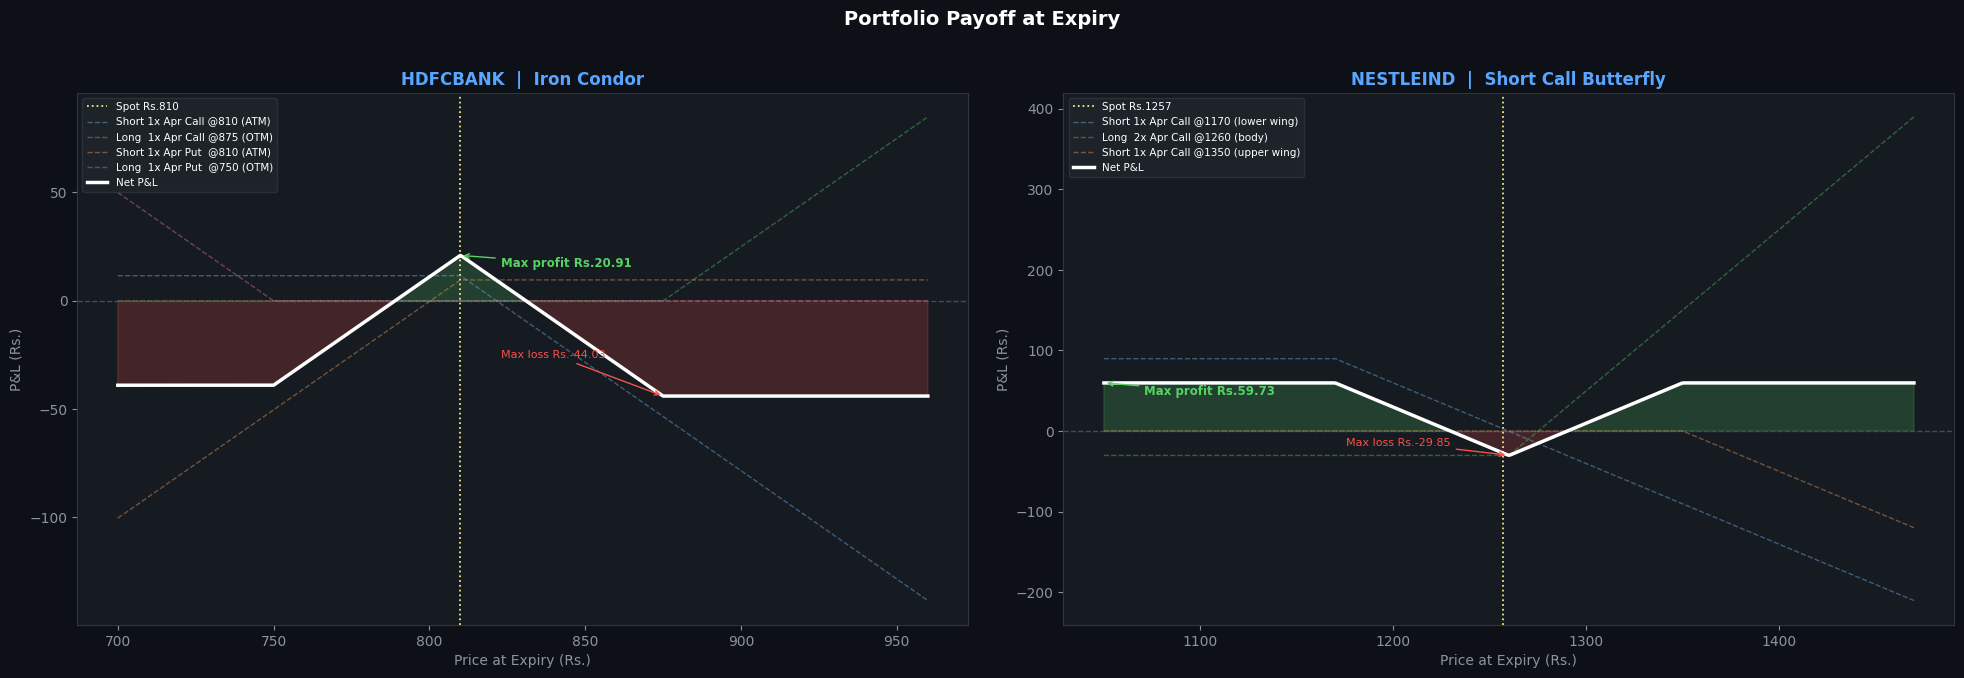

In [78]:
def expiry_pnl(legs, S_range, S0, r):
    total = np.zeros(len(S_range))
    leg_pnls = []
    for qty, direction, otype, K, T, vol, label in legs:
        premium = qty * bsm(S0, K, r, vol, T, otype)[0]
        payoff  = np.array([qty*(max(s-K,0) if otype=='Call' else max(K-s,0)) for s in S_range])
        pnl     = payoff - premium
        total  += pnl
        leg_pnls.append((label, pnl))
    return total, leg_pnls
 
S_h = np.linspace(700,  960,  500)
S_n = np.linspace(1050, 1470, 500)
pnl_hdfc,   legs_h = expiry_pnl(HDFC_PORT,   S_h, S_hdfc,   r)
pnl_nestle, legs_n = expiry_pnl(NESTLE_PORT, S_n, S_nestle, r)
 
palette = ['#79c0ff', '#56d364', '#ffa657', '#f778ba']
fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.patch.set_facecolor('#0d1117')
 
def draw_payoff(ax, S_range, pnl, leg_pnls, spot, name, strategy):
    ax.set_facecolor('#161b22')
    ax.axhline(0, color='#444c56', lw=1, ls='--')
    ax.axvline(spot, color='#f0e68c', lw=1.3, ls=':', label=f'Spot Rs.{spot:.0f}')
    for i, (lbl, lp) in enumerate(leg_pnls):
        ax.plot(S_range, lp, lw=1, ls='--', alpha=0.4, color=palette[i%len(palette)], label=lbl)
    ax.fill_between(S_range, pnl, 0, where=(pnl >= 0), alpha=0.2, color='#56d364')
    ax.fill_between(S_range, pnl, 0, where=(pnl <  0), alpha=0.2, color='#f85149')
    ax.plot(S_range, pnl, lw=2.5, color='white', label='Net P&L')
    mx = pnl.max(); mn = pnl.min()
    ax.annotate(f'Max profit Rs.{mx:.2f}',
                xy=(S_range[pnl.argmax()], mx),
                xytext=(S_range[pnl.argmax()] + (S_range[-1]-S_range[0])*0.05, mx*0.75),
                color='#56d364', fontsize=8.5, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#56d364'))
    ax.annotate(f'Max loss Rs.{mn:.2f}',
                xy=(S_range[pnl.argmin()], mn),
                xytext=(S_range[pnl.argmin()] - (S_range[-1]-S_range[0])*0.2, mn*0.6),
                color='#f85149', fontsize=8,
                arrowprops=dict(arrowstyle='->', color='#f85149'))
    ax.set_title(f'{name}  |  {strategy}', fontsize=12, color='#58a6ff', fontweight='bold')
    ax.set_xlabel('Price at Expiry (Rs.)', color='#8b949e')
    ax.set_ylabel('P&L (Rs.)', color='#8b949e')
    ax.tick_params(colors='#8b949e')
    ax.legend(fontsize=7.5, facecolor='#21262d', edgecolor='#30363d', labelcolor='white')
    for sp in ax.spines.values(): sp.set_edgecolor('#30363d')
 
draw_payoff(axes[0], S_h, pnl_hdfc,   legs_h, S_hdfc,   'HDFCBANK',  'Iron Condor')
draw_payoff(axes[1], S_n, pnl_nestle, legs_n, S_nestle, 'NESTLEIND', 'Short Call Butterfly')
fig.suptitle('Portfolio Payoff at Expiry', fontsize=14, color='white', fontweight='bold')
plt.tight_layout(pad=2)
plt.savefig('part2_payoff.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()


In [79]:
#part 3
hdfc   = df[df['Stock'] == 'HDFCBANK'].reset_index(drop=True)
nestle = df[df['Stock'] == 'NESTLEIND'].reset_index(drop=True)
 
S_hdfc   = hdfc['Spot'].iloc[0]
S_nestle = nestle['Spot'].iloc[0]
r        = hdfc['RFR'].iloc[0]
 
T_hdfc_apr = hdfc[hdfc['Expiry'].str.contains('Apr')]['T (Years)'].iloc[0]
T_ne_apr   = nestle[nestle['Expiry'].str.contains('Apr')]['T (Years)'].iloc[0]
 
vol_hdfc   = hdfc['Vol (Hist)'].iloc[0]
vol_nestle = nestle['Vol (Hist)'].iloc[0]

In [80]:
def bsm_price(S, K, r, sigma, T, opt_type):
    if T <= 0 or sigma <= 0:
        return max(S-K, 0) if opt_type == 'Call' else max(K-S, 0)
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    d2 = d1 - sigma*np.sqrt(T)
    if opt_type == 'Call':
        return S*norm.cdf(d1) - K*np.exp(-r*T)*norm.cdf(d2)
    else:
        return K*np.exp(-r*T)*norm.cdf(-d2) - S*norm.cdf(-d1)
 
def bsm_delta(S, K, r, sigma, T, opt_type):
    if T <= 0 or sigma <= 0:
        return 1.0 if opt_type == 'Call' else -1.0
    d1 = (np.log(S/K) + (r + 0.5*sigma**2)*T) / (sigma*np.sqrt(T))
    return norm.cdf(d1) if opt_type == 'Call' else norm.cdf(d1) - 1
 
def port_value(legs, S, r, vol_mult=1.0):
    return sum(qty * bsm_price(S, K, r, vol*vol_mult, T, otype)
               for qty, _, otype, K, T, vol, __ in legs)
 
def port_delta(legs, S, r, vol_mult=1.0):
    return sum(qty * bsm_delta(S, K, r, vol*vol_mult, T, otype)
               for qty, _, otype, K, T, vol, __ in legs)

In [81]:
HDFC_PORT = [
    (-1, 'Short', 'Call', 810,  T_hdfc_apr, vol_hdfc,   'Short 1x Apr Call @810'),
    (+1, 'Long',  'Call', 875,  T_hdfc_apr, vol_hdfc,   'Long  1x Apr Call @875'),
    (-1, 'Short', 'Put',  810,  T_hdfc_apr, vol_hdfc,   'Short 1x Apr Put  @810'),
    (+1, 'Long',  'Put',  750,  T_hdfc_apr, vol_hdfc,   'Long  1x Apr Put  @750'),
]
NESTLE_PORT = [
    (-1, 'Short', 'Call', 1170, T_ne_apr,   vol_nestle, 'Short 1x Apr Call @1170'),
    (+2, 'Long',  'Call', 1260, T_ne_apr,   vol_nestle, 'Long  2x Apr Call @1260'),
    (-1, 'Short', 'Call', 1350, T_ne_apr,   vol_nestle, 'Short 1x Apr Call @1350'),
]
 

In [82]:
base_hdfc   = port_value(HDFC_PORT,   S_hdfc,   r, vol_mult=1.0)
base_nestle = port_value(NESTLE_PORT, S_nestle, r, vol_mult=1.0)
 
hdfc_shares   = -port_delta(HDFC_PORT,   S_hdfc,   r, vol_mult=1.0)
nestle_shares = -port_delta(NESTLE_PORT, S_nestle, r, vol_mult=1.0)
 
print(f"Base HDFC portfolio value   : Rs.{base_hdfc:.4f}")
print(f"Base NESTLE portfolio value : Rs.{base_nestle:.4f}")
print(f"HDFC hedge shares           : {hdfc_shares:+.4f}")
print(f"NESTLE hedge shares         : {nestle_shares:+.4f}")

Base HDFC portfolio value   : Rs.-20.9691
Base NESTLE portfolio value : Rs.-59.7302
HDFC hedge shares           : +0.0677
NESTLE hedge shares         : -0.0060


In [83]:
price_shocks = [-0.02, -0.01, 0.00, +0.01, +0.02]
vol_mults    = [0.80,   1.00,  1.20]
price_labels = ['-2%', '-1%',  '0%', '+1%', '+2%']
vol_labels   = ['-20% Vol', 'Base Vol', '+20% Vol']
 
def build_pnl_table(legs, S0, r, base_val, hedge_shares, name):
    rows = []
    for vm, vl in zip(vol_mults, vol_labels):
        row = {'Portfolio': name, 'Vol Scenario': vl}
        for ps, pl in zip(price_shocks, price_labels):
            S_new   = S0 * (1 + ps)
            new_val = port_value(legs, S_new, r, vm)
            pnl_uh  = new_val - base_val
            pnl_h   = pnl_uh + hedge_shares * (S_new - S0)
            row[f'{pl} Unhedged'] = round(pnl_uh, 2)
            row[f'{pl} Hedged']   = round(pnl_h,  2)
        rows.append(row)
    return pd.DataFrame(rows)
 
hdfc_pnl   = build_pnl_table(HDFC_PORT,   S_hdfc,   r, base_hdfc,   hdfc_shares,   'HDFCBANK')
nestle_pnl = build_pnl_table(NESTLE_PORT, S_nestle, r, base_nestle, nestle_shares, 'NESTLEIND')

In [84]:
pd.set_option('display.width', 220)
for pnl_df, name in [(hdfc_pnl,   'HDFCBANK  — Iron Condor'),
                     (nestle_pnl, 'NESTLEIND — Short Call Butterfly')]:
    print(f"\n{'='*110}")
    print(f"P&L SCENARIOS: {name}")
    print(f"{'='*110}")
    print(pnl_df.drop(columns='Portfolio').to_string(index=False))


P&L SCENARIOS: HDFCBANK  — Iron Condor
Vol Scenario  -2% Unhedged  -2% Hedged  -1% Unhedged  -1% Hedged  0% Unhedged  0% Hedged  +1% Unhedged  +1% Hedged  +2% Unhedged  +2% Hedged
    -20% Vol        0.6300     -0.4600        3.5100      2.9600       4.0500     4.0500        2.2100      2.7500       -1.7300     -0.6400
    Base Vol       -2.5600     -3.6500       -0.3800     -0.9300       0.0000     0.0000       -1.4500     -0.9000       -4.5300     -3.4300
    +20% Vol       -5.6600     -6.7600       -4.0300     -4.5800      -3.7700    -3.7700       -4.9100     -4.3600       -7.3100     -6.2100

P&L SCENARIOS: NESTLEIND — Short Call Butterfly
Vol Scenario  -2% Unhedged  -2% Hedged  -1% Unhedged  -1% Hedged  0% Unhedged  0% Hedged  +1% Unhedged  +1% Hedged  +2% Unhedged  +2% Hedged
    -20% Vol        1.7700      1.9200       -3.9100     -3.8300      -5.8500    -5.8500       -3.7600     -3.8400        1.9300      1.7800
    Base Vol        5.8700      6.0200        1.4800      1.5500 

In [85]:
print(f"\n{'='*70}")
print("HEDGING EFFECTIVENESS  (base vol, avg |PnL| at +-2% price shock)")
print(f"{'='*70}")
for pnl_df, name in [(hdfc_pnl, 'HDFCBANK'), (nestle_pnl, 'NESTLEIND')]:
    bv     = pnl_df[pnl_df['Vol Scenario'] == 'Base Vol'].iloc[0]
    avg_uh = (abs(bv['-2% Unhedged']) + abs(bv['+2% Unhedged'])) / 2
    avg_h  = (abs(bv['-2% Hedged'])   + abs(bv['+2% Hedged']))   / 2
    red    = (1 - avg_h/avg_uh) * 100 if avg_uh > 0 else 0
    print(f"  {name:12}  Avg |Unhedged|: Rs.{avg_uh:.2f}  "
          f"Avg |Hedged|: Rs.{avg_h:.2f}  Reduction: {red:.1f}%")


HEDGING EFFECTIVENESS  (base vol, avg |PnL| at +-2% price shock)
  HDFCBANK      Avg |Unhedged|: Rs.3.54  Avg |Hedged|: Rs.3.54  Reduction: 0.1%
  NESTLEIND     Avg |Unhedged|: Rs.5.93  Avg |Hedged|: Rs.5.93  Reduction: 0.0%


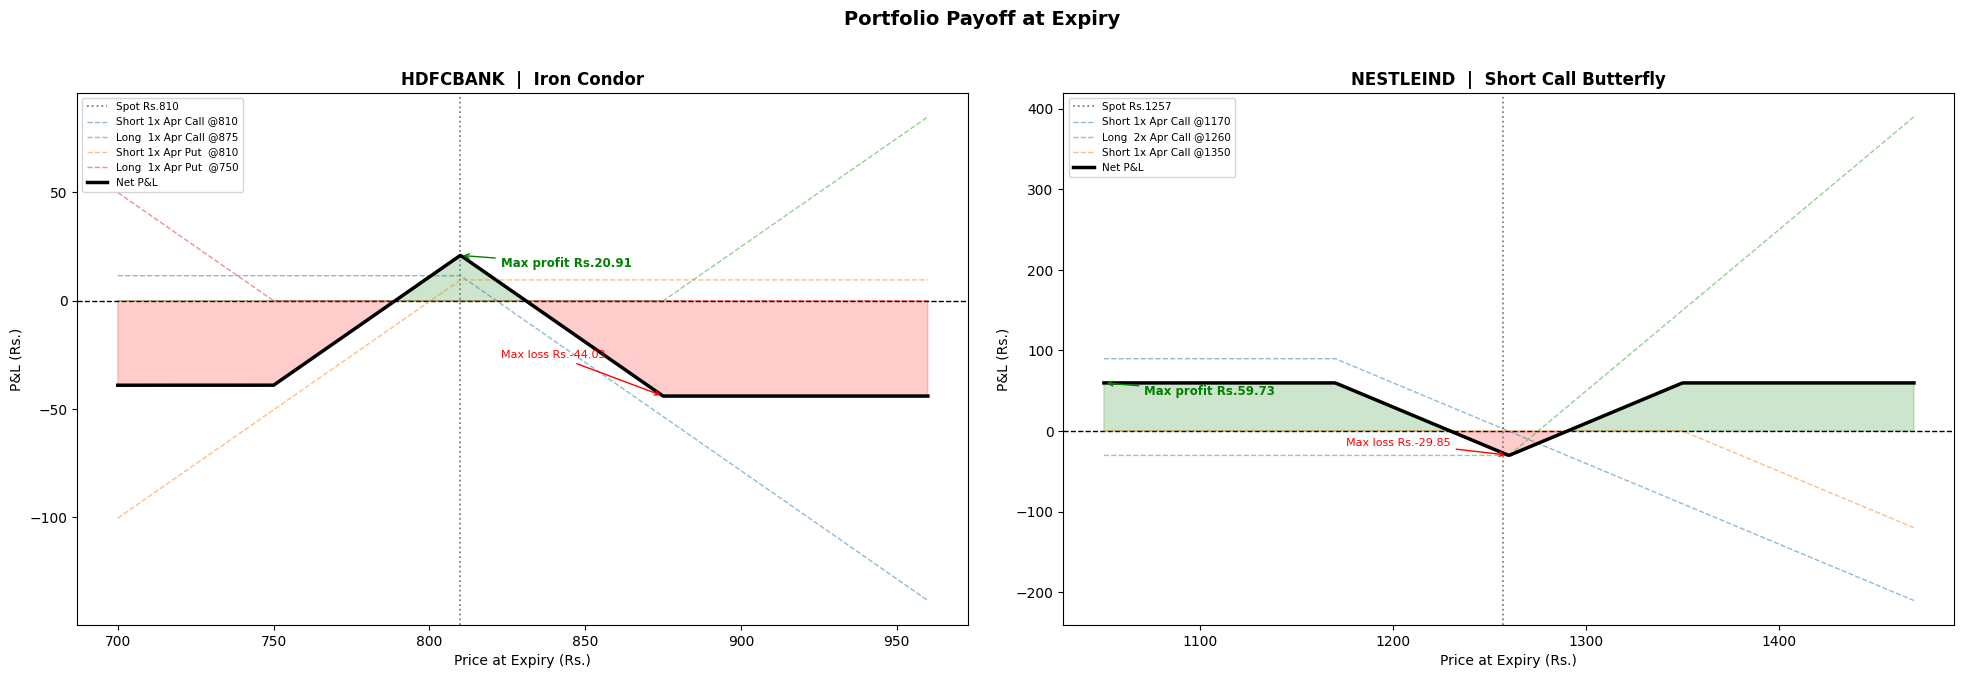

In [68]:
# Use default (white) style
plt.style.use('default')

def expiry_pnl(legs, S_range, S0, r):
    total = np.zeros(len(S_range))
    leg_pnls = []
    for qty, direction, otype, K, T, vol, label in legs:
        premium = qty * bsm(S0, K, r, vol, T, otype)[0]
        payoff  = np.array([qty*(max(s-K,0) if otype=='Call' else max(K-s,0)) for s in S_range])
        pnl     = payoff - premium
        total  += pnl
        leg_pnls.append((label, pnl))
    return total, leg_pnls

S_h = np.linspace(700,  960,  500)
S_n = np.linspace(1050, 1470, 500)
pnl_hdfc,   legs_h = expiry_pnl(HDFC_PORT,   S_h, S_hdfc,   r)
pnl_nestle, legs_n = expiry_pnl(NESTLE_PORT, S_n, S_nestle, r)

# Softer palette for white background
palette = ['#1f77b4', '#2ca02c', '#ff7f0e', '#d62728']

fig, axes = plt.subplots(1, 2, figsize=(20, 7))
fig.patch.set_facecolor('white')

def draw_payoff(ax, S_range, pnl, leg_pnls, spot, name, strategy):
    ax.set_facecolor('white')
    ax.axhline(0, color='black', lw=1, ls='--')
    ax.axvline(spot, color='grey', lw=1.3, ls=':', label=f'Spot Rs.{spot:.0f}')

    for i, (lbl, lp) in enumerate(leg_pnls):
        ax.plot(S_range, lp, lw=1, ls='--', alpha=0.5,
                color=palette[i % len(palette)], label=lbl)

    # P&L shading (green/red retained but softer)
    ax.fill_between(S_range, pnl, 0, where=(pnl >= 0), alpha=0.2, color='green')
    ax.fill_between(S_range, pnl, 0, where=(pnl <  0), alpha=0.2, color='red')

    ax.plot(S_range, pnl, lw=2.5, color='black', label='Net P&L')

    mx = pnl.max(); mn = pnl.min()

    ax.annotate(f'Max profit Rs.{mx:.2f}',
                xy=(S_range[pnl.argmax()], mx),
                xytext=(S_range[pnl.argmax()] + (S_range[-1]-S_range[0])*0.05, mx*0.75),
                color='green', fontsize=8.5, fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='green'))

    ax.annotate(f'Max loss Rs.{mn:.2f}',
                xy=(S_range[pnl.argmin()], mn),
                xytext=(S_range[pnl.argmin()] - (S_range[-1]-S_range[0])*0.2, mn*0.6),
                color='red', fontsize=8,
                arrowprops=dict(arrowstyle='->', color='red'))

    ax.set_title(f'{name}  |  {strategy}', fontsize=12, color='black', fontweight='bold')
    ax.set_xlabel('Price at Expiry (Rs.)', color='black')
    ax.set_ylabel('P&L (Rs.)', color='black')
    ax.tick_params(colors='black')

    ax.legend(fontsize=7.5)

    for sp in ax.spines.values():
        sp.set_edgecolor('black')


draw_payoff(axes[0], S_h, pnl_hdfc,   legs_h, S_hdfc,   'HDFCBANK',  'Iron Condor')
draw_payoff(axes[1], S_n, pnl_nestle, legs_n, S_nestle, 'NESTLEIND', 'Short Call Butterfly')

fig.suptitle('Portfolio Payoff at Expiry', fontsize=14, color='black', fontweight='bold')

plt.tight_layout(pad=2)
plt.savefig('part2_payoff.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

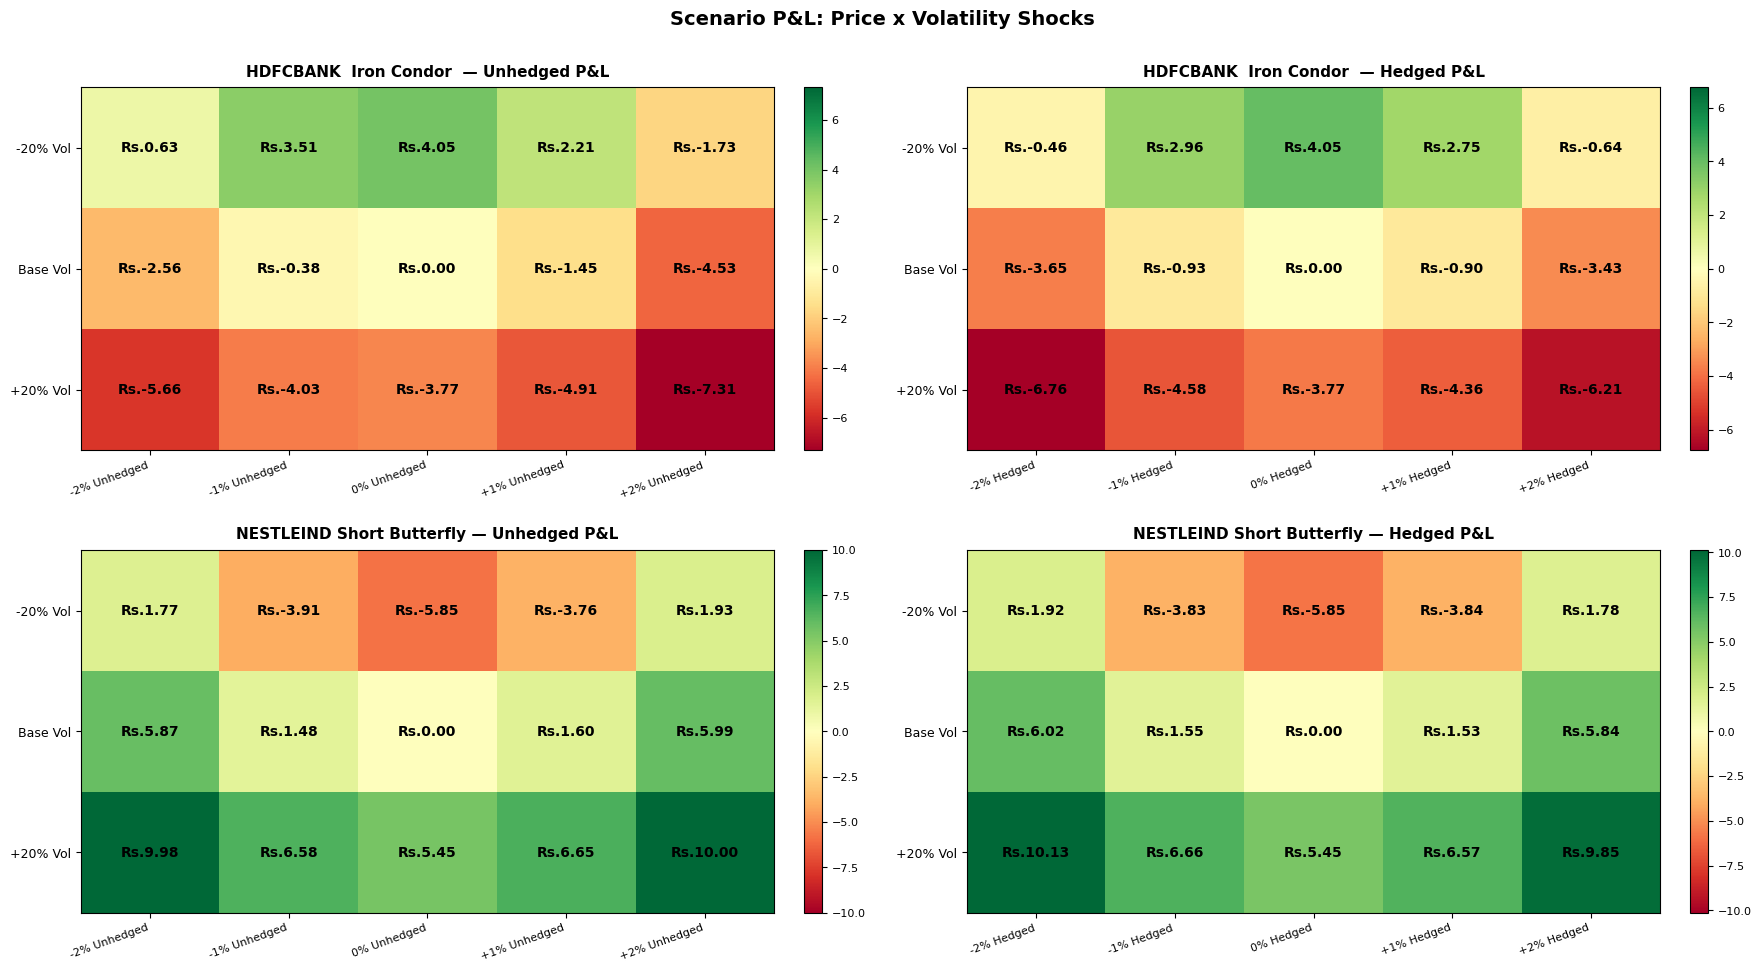

In [69]:
plt.style.use('default')

fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.patch.set_facecolor('white')

uh_cols = [f'{p} Unhedged' for p in price_labels]
h_cols  = [f'{p} Hedged'   for p in price_labels]

def heatmap(ax, pnl_df, cols, title):
    ax.set_facecolor('white')

    vals = pnl_df[cols].values.astype(float)
    vmax = max(np.abs(vals).max(), 1e-6)

    # Softer, print-friendly colormap
    im = ax.imshow(vals, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)

    ax.set_xticks(range(len(cols)))
    ax.set_xticklabels(cols, fontsize=8, rotation=20, ha='right', color='black')

    ax.set_yticks(range(len(vol_labels)))
    ax.set_yticklabels(vol_labels, fontsize=9, color='black')

    for row in range(vals.shape[0]):
        for col in range(vals.shape[1]):
            v = vals[row, col]
            tc = 'black'  # force black text for clarity
            ax.text(col, row, f'Rs.{v:.2f}',
                    ha='center', va='center',
                    fontsize=10, fontweight='bold', color=tc)

    cb = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.04)
    cb.ax.yaxis.set_tick_params(labelsize=8, colors='black')

    ax.set_title(title, fontsize=11, color='black', fontweight='bold', pad=8)

    for sp in ax.spines.values():
        sp.set_edgecolor('black')

heatmap(axes[0][0], hdfc_pnl,   uh_cols, 'HDFCBANK  Iron Condor  — Unhedged P&L')
heatmap(axes[0][1], hdfc_pnl,   h_cols,  'HDFCBANK  Iron Condor  — Hedged P&L')
heatmap(axes[1][0], nestle_pnl, uh_cols, 'NESTLEIND Short Butterfly — Unhedged P&L')
heatmap(axes[1][1], nestle_pnl, h_cols,  'NESTLEIND Short Butterfly — Hedged P&L')

fig.suptitle('Scenario P&L: Price x Volatility Shocks',
             fontsize=14, color='black', fontweight='bold')

plt.tight_layout(pad=2)
plt.savefig('part3_heatmaps.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()